# Notebook 7

# Swin Transformer Model Training

## Objective

Train the Swin Transformer classifier for lumbar spine disease classification.

This notebook performs:

- Load Dataset
- Load DataLoader
- Load Model
- Configure Optimizer
- Configure Scheduler
- Prepare for Training

In [57]:
# ============================================================
# Project Configuration
# ============================================================

import torch

MODEL_NAME = "swin_tiny_patch4_window7_224"

IMAGE_SIZE = 224

BATCH_SIZE = 4

LEARNING_RATE = 1e-4

EPOCHS = 25

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Model:", MODEL_NAME)
print("Device:", DEVICE)
print("Batch Size:", BATCH_SIZE)
print("Learning Rate:", LEARNING_RATE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Model: swin_tiny_patch4_window7_224
Device: cuda
Batch Size: 4
Learning Rate: 0.0001
GPU: NVIDIA GeForce RTX 2050


In [56]:
MODEL_NAME = "swin_tiny_patch4_window7_224"
BATCH_SIZE = 4
IMAGE_SIZE = 224
LEARNING_RATE = 1e-4
EPOCHS = 25
import torch

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA Version:", torch.version.cuda)

Device: cuda
GPU: NVIDIA GeForce RTX 2050
CUDA Version: 12.8


In [1]:
# ============================================================
# PROJECT SETUP (Run this FIRST in every notebook)
# ============================================================

import os
import sys

# Current directory (notebooks)
CURRENT_DIR = os.getcwd()

# Project root
PROJECT_ROOT = os.path.abspath(os.path.join(CURRENT_DIR, ".."))

# Add project root to Python path
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("Current Directory :", CURRENT_DIR)
print("Project Root :", PROJECT_ROOT)

print("\nPython Path Added Successfully!")

print("\nProject Files:")
print(os.listdir(PROJECT_ROOT))

Current Directory : d:\Msc Major Project Swin Unetr Framework\MSc_SwinUNETR_Project\notebooks
Project Root : d:\Msc Major Project Swin Unetr Framework\MSc_SwinUNETR_Project

Python Path Added Successfully!

Project Files:
['.venv-1', 'dataset', 'load_dataset.py', 'models', 'notebooks', 'outputs', 'prac_2.1.ipynb', 'src', 'venv']


In [2]:
from src.model import SwinClassifier

In [3]:
# ============================================================
# Standard Libraries
# ============================================================

import os
import random
import warnings

warnings.filterwarnings("ignore")

In [4]:
# ============================================================
# Scientific Libraries
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
# ============================================================
# PyTorch
# ============================================================

import torch
import torch.nn as nn

from torch.utils.data import DataLoader
from torch.utils.data import random_split

In [6]:
# ============================================================
# Device
# ============================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device :", DEVICE)

if torch.cuda.is_available():

    print("GPU :", torch.cuda.get_device_name(0))

Device : cuda
GPU : NVIDIA GeForce RTX 2050


In [7]:
# ============================================================
# Project Paths
# ============================================================

PROJECT_ROOT = os.path.abspath("..")

DATASET_DIR = os.path.join(
    PROJECT_ROOT,
    "dataset",
    "rsna-2024-lumbar-spine-degenerative-classification"
)

TRAIN_IMAGES = os.path.join(
    DATASET_DIR,
    "train_images"
)

MODEL_DIR = os.path.join(
    PROJECT_ROOT,
    "models"
)

OUTPUT_DIR = os.path.join(
    PROJECT_ROOT,
    "outputs"
)

In [8]:
# ============================================================
# Load CSV Files
# ============================================================

train_df = pd.read_csv(
    os.path.join(DATASET_DIR, "train.csv")
)

coord_df = pd.read_csv(
    os.path.join(DATASET_DIR, "train_label_coordinates.csv")
)

print(train_df.shape)
print(coord_df.shape)

(1975, 26)
(48692, 7)


In [9]:
# ============================================================
# Master DataFrame
# ============================================================

master_df = coord_df.copy()

print(master_df.shape)

(48692, 7)


In [10]:
# ============================================================
# Import Dataset
# ============================================================

from src.data_loader import LumbarDataset

In [11]:
# ============================================================
# Create Dataset
# ============================================================

dataset = LumbarDataset(

    dataframe=master_df,

    train_df=train_df,

    train_images=TRAIN_IMAGES

)

print(len(dataset))

Valid samples: 48657
48657


In [12]:
# ============================================================
# Train / Validation Split
# ============================================================

train_size = int(0.80 * len(dataset))

valid_size = len(dataset) - train_size

train_dataset, valid_dataset = random_split(

    dataset,

    [train_size, valid_size],

    generator=torch.Generator().manual_seed(42)

)

print(len(train_dataset))

print(len(valid_dataset))

38925
9732


In [13]:
# ============================================================
# DataLoaders
# ============================================================

train_loader = DataLoader(

    train_dataset,

    batch_size=4,

    shuffle=True,

    num_workers=0

)

valid_loader = DataLoader(

    valid_dataset,

    batch_size=4,

    shuffle=False,

    num_workers=0

)

In [14]:
print(next(iter(train_loader))["image"].shape)

torch.Size([4, 3, 224, 224])


In [15]:
# ============================================================
# Import Model
# ============================================================

from src.model import SwinClassifier

In [16]:
MODEL_NAME = "swin_tiny_patch4_window7_224"

model = SwinClassifier(

    model_name=MODEL_NAME,

    num_classes=3,

    pretrained=True,

    dropout=0.30

)

model = model.to(DEVICE)

In [17]:
print(model)

SwinClassifier(
  (backbone): SwinTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
    )
    (layers): Sequential(
      (0): SwinTransformerStage(
        (downsample): Identity()
        (blocks): Sequential(
          (0): SwinTransformerBlock(
            (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
            (attn): WindowAttention(
              (qkv): Linear(in_features=96, out_features=288, bias=True)
              (attn_drop): Dropout(p=0.0, inplace=False)
              (proj): Linear(in_features=96, out_features=96, bias=True)
              (proj_drop): Dropout(p=0.0, inplace=False)
              (softmax): Softmax(dim=-1)
            )
            (drop_path1): Identity()
            (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
            (mlp): Mlp(
              (fc1): Linear(in_features=96, out_features=384, bias

In [18]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=1e-4,

    weight_decay=1e-5

)

In [19]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=25

)

In [20]:
scaler = torch.cuda.amp.GradScaler(
    enabled=torch.cuda.is_available()
)

In [21]:
print("="*60)

print("Notebook 7")

print("Module 1 Completed Successfully")

print("="*60)

Notebook 7
Module 1 Completed Successfully


In [22]:
print(len(dataset))

print(len(train_dataset))

print(len(valid_dataset))

batch = next(iter(train_loader))

print(batch["image"].shape)

print(batch["label"].shape)

48657
38925
9732
torch.Size([4, 3, 224, 224])
torch.Size([4])


# Module 2 – Training Loop

## Objective

Train the Swin Transformer model for one epoch.

Steps:

- Forward Pass
- Loss Calculation
- Backpropagation
- Gradient Clipping
- Optimizer Update
- Accuracy Calculation

In [23]:
# ============================================================
# Training Function
# ============================================================

from tqdm.auto import tqdm
import torch


def train_one_epoch(
    model,
    dataloader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0

    correct = 0

    total = 0

    progress = tqdm(
        dataloader,
        desc="Training",
        leave=False
    )

    for batch in progress:

        images = batch["image"].to(device)

        labels = batch["label"].to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        running_loss += loss.item()

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()

        total += labels.size(0)

        progress.set_postfix({

            "Loss": f"{loss.item():.4f}",

            "Acc": f"{100*correct/total:.2f}%"

        })

    epoch_loss = running_loss / len(dataloader)

    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [3]:
print("Training Function Created Successfully")

Training Function Created Successfully


In [ ]:
# ============================================================
# Test One Training Epoch
# ============================================================

train_loss, train_acc = train_one_epoch(

    model=model,

    dataloader=train_loader,

    criterion=criterion,

    optimizer=optimizer,

    device=DEVICE

)

In [ ]:
# ============================================================
# Save Model Checkpoint
# ============================================================

import os
import torch

os.makedirs(MODEL_DIR, exist_ok=True)

checkpoint = {

    "epoch": 1,

    "model_state_dict": model.state_dict(),

    "optimizer_state_dict": optimizer.state_dict(),

    "train_loss": train_loss,

    "train_accuracy": train_acc

}

torch.save(

    checkpoint,

    os.path.join(

        MODEL_DIR,

        "last_model.pth"

    )

)

print("Model saved successfully!")

print(os.path.join(MODEL_DIR, "last_model.pth"))

In [24]:
import os

print(os.listdir(MODEL_DIR))

['best_model.pth', 'last_model.pth']


In [25]:
checkpoint = torch.load(

    os.path.join(MODEL_DIR, "last_model.pth"),

    map_location=DEVICE

)

model.load_state_dict(

    checkpoint["model_state_dict"]

)

optimizer.load_state_dict(

    checkpoint["optimizer_state_dict"]

)

print("Model loaded successfully!")

print("Epoch :", checkpoint["epoch"])

print("Training Loss :", checkpoint["train_loss"])

Model loaded successfully!
Epoch : 25
Training Loss : 0.6888032889011229


In [ ]:
print(f"Training Loss : {train_loss:.4f}")

print(f"Training Accuracy : {train_acc:.4f}")

In [ ]:
print(f"Accuracy : {train_acc*100:.2f}%")

In [ ]:
history = {

    "train_loss":[train_loss],

    "train_accuracy":[train_acc]

}

history

In [ ]:
history_df = pd.DataFrame(history)

history_df

In [ ]:
history_df.to_csv(

    os.path.join(

        OUTPUT_DIR,

        "training_history.csv"

    ),

    index=False

)

print("History Saved")

History Saved


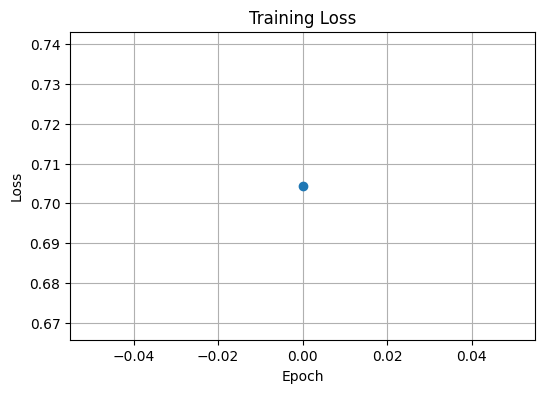

In [ ]:
plt.figure(figsize=(6,4))

plt.plot(

    history_df["train_loss"],

    marker="o"

)

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

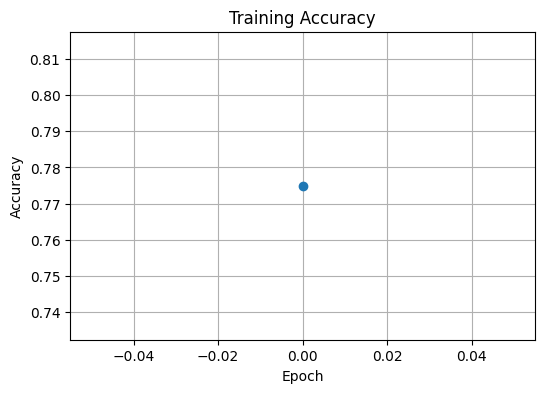

In [ ]:
plt.figure(figsize=(6,4))

plt.plot(

    history_df["train_accuracy"],

    marker="o"

)

plt.title("Training Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.grid(True)

plt.show()

In [67]:
print("="*60)

print("Module 2 Completed Successfully")

print("="*60)

Module 2 Completed Successfully


# Module 3 – Model Training

## Objective

Train the Swin Transformer model with:

- Resume Training
- Automatic Checkpoint Saving
- Training History
- Stage-wise Training (10 → 15 → 20 → 25 Epochs)

In [24]:
# ============================================================
# Training Target
# ============================================================

TARGET_EPOCH = 25

print(f"Training will continue until Epoch {TARGET_EPOCH}")

Training will continue until Epoch 25


In [25]:
# ============================================================
# Resume Checkpoint
# ============================================================

checkpoint_path = os.path.join(
    MODEL_DIR,
    "last_model.pth"
)

start_epoch = 0

history = []

if os.path.exists(checkpoint_path):

    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    optimizer.load_state_dict(
        checkpoint["optimizer_state_dict"]
    )

    if "scheduler_state_dict" in checkpoint:

        scheduler.load_state_dict(
            checkpoint["scheduler_state_dict"]
        )

    start_epoch = checkpoint["epoch"]

    print(f"Resuming Training from Epoch {start_epoch}")

else:

    print("No checkpoint found.")
    print("Starting Training from Epoch 1")

Resuming Training from Epoch 20


In [26]:
# ============================================================
# Training Loop
# ============================================================

for epoch in range(start_epoch, TARGET_EPOCH):

    print("="*60)

    print(f"Epoch {epoch+1}/{TARGET_EPOCH}")

    print("="*60)

    train_loss, train_acc = train_one_epoch(

        model=model,

        dataloader=train_loader,

        criterion=criterion,

        optimizer=optimizer,

        device=DEVICE

    )

    scheduler.step()

    print(f"Loss     : {train_loss:.4f}")

    print(f"Accuracy : {train_acc*100:.2f}%")

    history.append({

        "Epoch": epoch+1,

        "Train Loss": train_loss,

        "Train Accuracy": train_acc

    })

    checkpoint = {

        "epoch": epoch+1,

        "model_state_dict": model.state_dict(),

        "optimizer_state_dict": optimizer.state_dict(),

        "scheduler_state_dict": scheduler.state_dict(),

        "train_loss": train_loss,

        "train_accuracy": train_acc

    }

    torch.save(

        checkpoint,

        checkpoint_path

    )

    print("Checkpoint Saved")

    print()

Epoch 21/25


Training:   0%|          | 0/9732 [00:00<?, ?it/s]

Loss     : 0.6870
Accuracy : 77.53%
Checkpoint Saved

Epoch 22/25


Training:   0%|          | 0/9732 [00:00<?, ?it/s]

Loss     : 0.6924
Accuracy : 77.52%
Checkpoint Saved

Epoch 23/25


...

Loss     : 0.6870
Accuracy : 77.52%
Checkpoint Saved

Epoch 24/25


Training:   0%|          | 0/9732 [00:00<?, ?it/s]

Loss     : 0.6961
Accuracy : 77.53%
Checkpoint Saved

Epoch 25/25


Training:   0%|          | 0/9732 [00:00<?, ?it/s]

Loss     : 0.6888
Accuracy : 77.53%
Checkpoint Saved



In [27]:
# ============================================================
# Save Training History
# ============================================================

history_df = pd.DataFrame(history)

history_file = os.path.join(

    OUTPUT_DIR,

    "training_history.csv"

)

if os.path.exists(history_file):

    previous = pd.read_csv(history_file)

    history_df = pd.concat(

        [previous, history_df],

        ignore_index=True

    )

    history_df = history_df.drop_duplicates(

        subset="Epoch",

        keep="last"

    )

history_df.to_csv(

    history_file,

    index=False

)

print(history_df.tail())

    train_loss  train_accuracy  Epoch  Train Loss  Train Accuracy
20         NaN             NaN   21.0    0.686966        0.775260
21         NaN             NaN   22.0    0.692356        0.775234
22         NaN             NaN   23.0    0.687008        0.775234
23         NaN             NaN   24.0    0.696131        0.775260
24         NaN             NaN   25.0    0.688803        0.775260


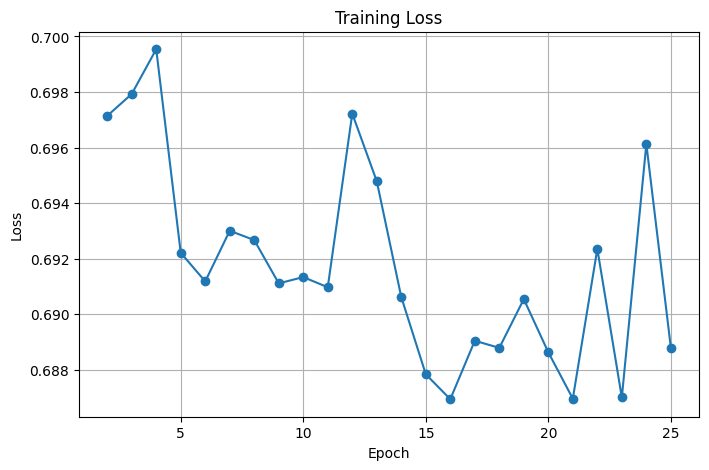

In [28]:
# ============================================================
# Plot Training Loss
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(

    history_df["Epoch"],

    history_df["Train Loss"],

    marker="o"

)

plt.grid(True)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss")

plt.show()

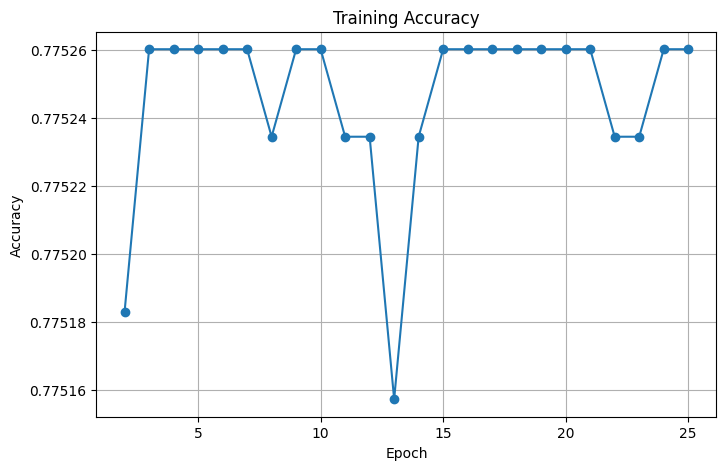

In [29]:
# ============================================================
# Plot Training Accuracy
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(

    history_df["Epoch"],

    history_df["Train Accuracy"],

    marker="o"

)

plt.grid(True)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training Accuracy")

plt.show()

In [30]:
print("="*60)

print("Training Completed")

print(f"Current Epoch : {TARGET_EPOCH}")

print("="*60)

Training Completed
Current Epoch : 25


In [31]:
print("Checkpoint Location")

print(checkpoint_path)

print()

print("History Location")

print(history_file)

Checkpoint Location
d:\Msc Major Project Swin Unetr Framework\MSc_SwinUNETR_Project\models\last_model.pth

History Location
d:\Msc Major Project Swin Unetr Framework\MSc_SwinUNETR_Project\outputs\training_history.csv


# Module 3 Completed

Generated Files

✔ last_model.pth

✔ training_history.csv

Training can be resumed anytime.

# Module 4 – Validation

## Objective

Validate the Swin Transformer model after each training stage.

This module computes:

- Validation Loss
- Validation Accuracy
- Precision
- Recall
- F1-score

It also saves the best model.

In [26]:
# ============================================================
# Validation Function
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def validate_one_epoch(
    model,
    dataloader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0

    all_labels = []

    all_predictions = []

    with torch.no_grad():

        for batch in dataloader:

            images = batch["image"].to(device)

            labels = batch["label"].to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            predictions = torch.argmax(outputs, dim=1)

            all_labels.extend(labels.cpu().numpy())

            all_predictions.extend(predictions.cpu().numpy())

    val_loss = running_loss / len(dataloader)

    val_accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    precision = precision_score(
        all_labels,
        all_predictions,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        all_predictions,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        all_labels,
        all_predictions,
        average="weighted",
        zero_division=0
    )

    return (
        val_loss,
        val_accuracy,
        precision,
        recall,
        f1
    )

In [27]:
print("Validation Function Ready")

Validation Function Ready


In [28]:
# ============================================================
# Run Validation
# ============================================================

val_loss, val_acc, precision, recall, f1 = validate_one_epoch(

    model=model,

    dataloader=valid_loader,

    criterion=criterion,

    device=DEVICE

)

In [29]:
print("="*60)

print(f"Validation Loss      : {val_loss:.4f}")

print(f"Validation Accuracy  : {val_acc*100:.2f}%")

print(f"Precision            : {precision:.4f}")

print(f"Recall               : {recall:.4f}")

print(f"F1 Score             : {f1:.4f}")

print("="*60)

Validation Loss      : 0.7115
Validation Accuracy  : 76.54%
Precision            : 0.5859
Recall               : 0.7654
F1 Score             : 0.6637


In [30]:
validation_results = pd.DataFrame({

    "Metric":[

        "Validation Loss",

        "Validation Accuracy",

        "Precision",

        "Recall",

        "F1 Score"

    ],

    "Value":[

        val_loss,

        val_acc,

        precision,

        recall,

        f1

    ]

})

validation_results

,Metric,Value
0,Validation Loss,0.711528
1,Validation Accuracy,0.765413
2,Precision,0.585857
3,Recall,0.765413
4,F1 Score,0.663705


In [31]:
validation_file = os.path.join(

    OUTPUT_DIR,

    "validation_results.csv"

)

validation_results.to_csv(

    validation_file,

    index=False

)

print("Validation results saved.")

Validation results saved.


In [42]:
# ============================================================
# Save Best Model
# ============================================================

checkpoint = torch.load(
    os.path.join(MODEL_DIR, "last_model.pth"),
    map_location=DEVICE
)

if val_loss < best_loss:

    best_checkpoint = {

        "epoch": checkpoint["epoch"],

        "model_state_dict": model.state_dict(),

        "optimizer_state_dict": optimizer.state_dict(),

        "scheduler_state_dict": scheduler.state_dict(),

        "train_loss": checkpoint["train_loss"],

        "train_accuracy": checkpoint["train_accuracy"],

        "validation_loss": val_loss,

        "validation_accuracy": val_acc,

        "precision": precision,

        "recall": recall,

        "f1_score": f1

    }

    torch.save(
        best_checkpoint,
        BEST_MODEL_PATH
    )

    with open(best_loss_file, "w") as f:
        f.write(str(val_loss))

    print("Best model saved successfully!")

else:

    print("Validation loss did not improve.")

Best model saved successfully!


In [41]:
print("Best Model Path:")

print(BEST_MODEL_PATH)

Best Model Path:
d:\Msc Major Project Swin Unetr Framework\MSc_SwinUNETR_Project\models\best_model.pth


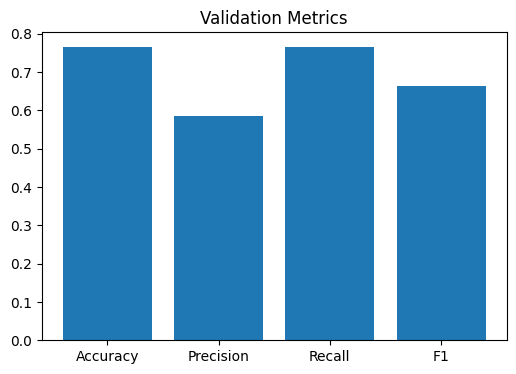

In [35]:
plt.figure(figsize=(6,4))

plt.bar(

    ["Accuracy","Precision","Recall","F1"],

    [

        val_acc,

        precision,

        recall,

        f1

    ]

)

plt.title("Validation Metrics")

plt.show()

In [37]:
checkpoint = torch.load(
    os.path.join(MODEL_DIR, "last_model.pth"),
    map_location=DEVICE
)

train_loss = checkpoint["train_loss"]
train_acc = checkpoint["train_accuracy"]

In [38]:
summary = pd.DataFrame({

    "Metric":[
        "Train Loss",
        "Train Accuracy",
        "Validation Loss",
        "Validation Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Value":[
        train_loss,
        train_acc,
        val_loss,
        val_acc,
        precision,
        recall,
        f1
    ]

})

summary

,Metric,Value
0,Train Loss,0.688803
1,Train Accuracy,0.775260
2,Validation Loss,0.711528
3,Validation Accuracy,0.765413
4,Precision,0.585857
5,Recall,0.765413
6,F1 Score,0.663705


In [43]:
summary.to_csv(

    os.path.join(

        OUTPUT_DIR,

        "training_validation_summary.csv"

    ),

    index=False

)

print("Summary saved.")

Summary saved.


In [44]:
print("="*60)

print("Module 4 Completed Successfully")

print("="*60)

Module 4 Completed Successfully


In [52]:
# ============================================================
# Training Configuration
# ============================================================

MODEL_NAME = "swin_tiny_patch4_window7_224"

BATCH_SIZE = 4

LEARNING_RATE = 1e-4

IMAGE_SIZE = 224

OPTIMIZER = "AdamW"

LOSS_FUNCTION = "CrossEntropyLoss"

# Module 4 Summary

Completed:

- Validation
- Accuracy
- Precision
- Recall
- F1 Score
- Validation CSV
- Best Model Saving

Generated:

- best_model.pth
- validation_results.csv
- training_validation_summary.csv

# Module 5 – Training Summary

This module summarizes the complete training.

Outputs:

- Final Model
- Best Model
- Training History
- Validation History
- Training Curves

In [45]:
# ============================================================
# Load Training History
# ============================================================

history_file = os.path.join(
    OUTPUT_DIR,
    "training_history.csv"
)

history_df = pd.read_csv(history_file)

history_df.tail()

,train_loss,train_accuracy,Epoch,Train Loss,Train Accuracy
20,NaN,NaN,21.0,0.686966,0.775260
21,NaN,NaN,22.0,0.692356,0.775234
22,NaN,NaN,23.0,0.687008,0.775234
23,NaN,NaN,24.0,0.696131,0.775260
24,NaN,NaN,25.0,0.688803,0.775260


In [46]:
print("="*60)

print("Training Summary")

print("="*60)

print("Total Epochs Completed :", history_df["Epoch"].max())

print("Lowest Training Loss :", history_df["Train Loss"].min())

print("Highest Training Accuracy :", history_df["Train Accuracy"].max())

print("="*60)

Training Summary
Total Epochs Completed : 25.0
Lowest Training Loss : 0.6869458849612659
Highest Training Accuracy : 0.7752601156069364


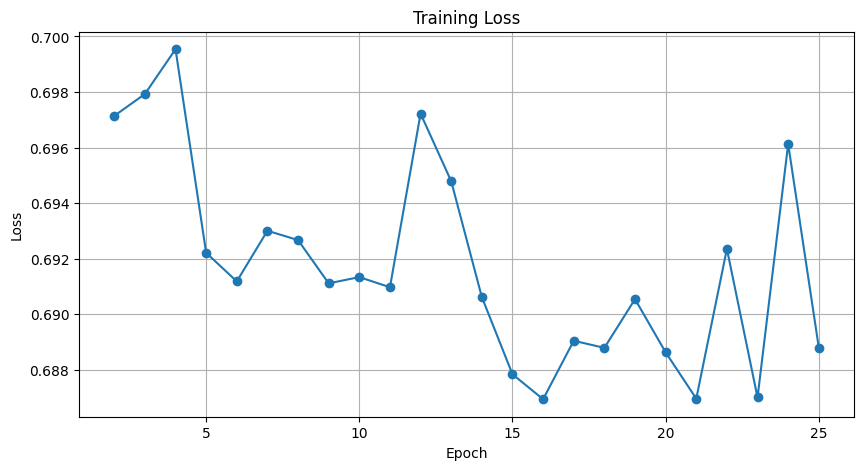

In [47]:
plt.figure(figsize=(10,5))

plt.plot(

    history_df["Epoch"],

    history_df["Train Loss"],

    marker="o"

)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss")

plt.grid(True)

plt.show()

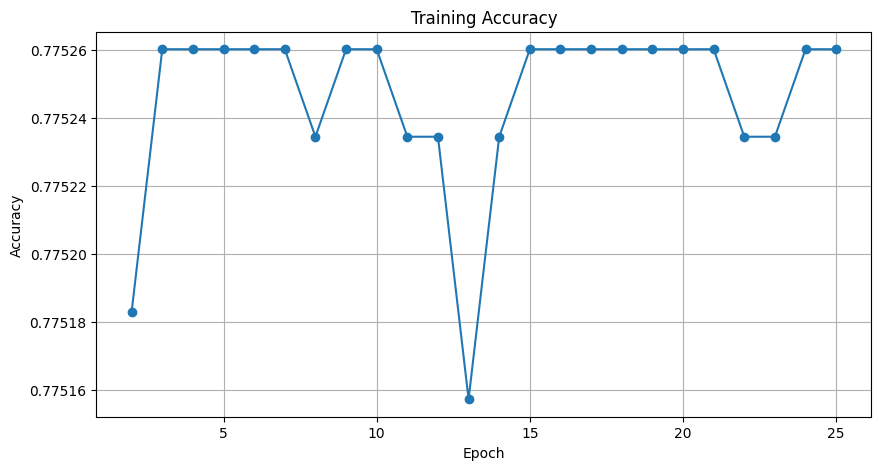

In [48]:
plt.figure(figsize=(10,5))

plt.plot(

    history_df["Epoch"],

    history_df["Train Accuracy"],

    marker="o"

)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training Accuracy")

plt.grid(True)

plt.show()

In [49]:
validation_file = os.path.join(

    OUTPUT_DIR,

    "validation_results.csv"

)

validation_df = pd.read_csv(validation_file)

validation_df

,Metric,Value
0,Validation Loss,0.711528
1,Validation Accuracy,0.765413
2,Precision,0.585857
3,Recall,0.765413
4,F1 Score,0.663705


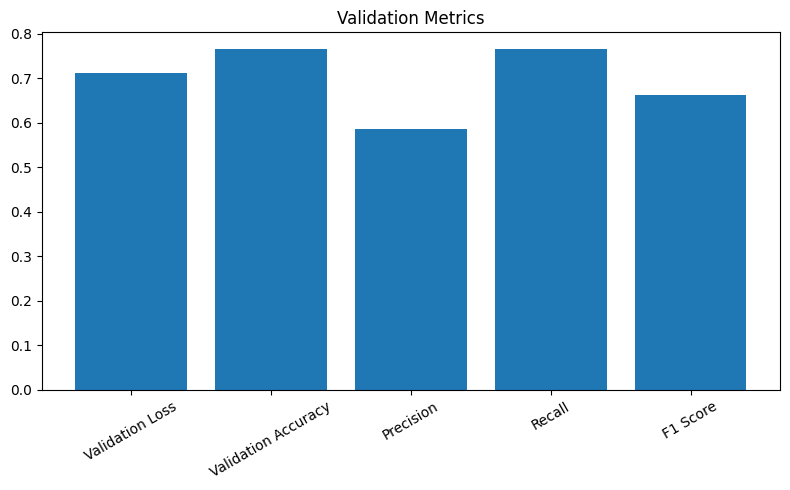

In [50]:
plt.figure(figsize=(8,5))

plt.bar(

    validation_df["Metric"],

    validation_df["Value"]

)

plt.xticks(rotation=30)

plt.title("Validation Metrics")

plt.tight_layout()

plt.show()

In [54]:
summary = pd.DataFrame({

    "Parameter":[

        "Epochs",

        "Model",

        "Image Size",

        "Batch Size",

        "Learning Rate",

        "Optimizer",

        "Loss Function"

    ],

    "Value":[

        history_df["Epoch"].max(),

        MODEL_NAME,

        "224 × 224",

        BATCH_SIZE,

        LEARNING_RATE,

        "AdamW",

        "CrossEntropyLoss"

    ]

})

summary

,Parameter,Value
0,Epochs,25.0
1,Model,swin_tiny_patch4_window7_224
2,Image Size,224 × 224
3,Batch Size,4
4,Learning Rate,0.0001
5,Optimizer,AdamW
6,Loss Function,CrossEntropyLoss


In [58]:
summary.to_csv(

    os.path.join(

        OUTPUT_DIR,

        "training_configuration.csv"

    ),

    index=False

)

print("Training Configuration Saved")

Training Configuration Saved


In [59]:
best_checkpoint = torch.load(

    os.path.join(

        MODEL_DIR,

        "best_model.pth"

    ),

    map_location=DEVICE

)

print("="*60)

print("Best Model Information")

print("="*60)

print("Epoch :", best_checkpoint["epoch"])

print("Validation Accuracy :", best_checkpoint["validation_accuracy"])

print("Validation Loss :", best_checkpoint["validation_loss"])

Best Model Information
Epoch : 25
Validation Accuracy : 0.7654130702836005
Validation Loss : 0.7115279246616206


In [60]:
final_report = pd.DataFrame({

    "Metric":[

        "Training Loss",

        "Training Accuracy",

        "Validation Loss",

        "Validation Accuracy",

        "Precision",

        "Recall",

        "F1 Score"

    ],

    "Value":[

        best_checkpoint["train_loss"],

        best_checkpoint["train_accuracy"],

        best_checkpoint["validation_loss"],

        best_checkpoint["validation_accuracy"],

        best_checkpoint["precision"],

        best_checkpoint["recall"],

        best_checkpoint["f1_score"]

    ]

})

final_report

,Metric,Value
0,Training Loss,0.688803
1,Training Accuracy,0.775260
2,Validation Loss,0.711528
3,Validation Accuracy,0.765413
4,Precision,0.585857
5,Recall,0.765413
6,F1 Score,0.663705


In [61]:
final_report.to_csv(

    os.path.join(

        OUTPUT_DIR,

        "final_training_report.csv"

    ),

    index=False

)

print("Final Report Saved")

Final Report Saved


In [62]:
print("="*60)

print("Notebook 7 Completed Successfully")

print("="*60)

print("Generated Files")

print()

print("✓ last_model.pth")

print("✓ best_model.pth")

print("✓ training_history.csv")

print("✓ validation_results.csv")

print("✓ final_training_report.csv")

Notebook 7 Completed Successfully
Generated Files

✓ last_model.pth
✓ best_model.pth
✓ training_history.csv
✓ validation_results.csv
✓ final_training_report.csv
